## 0. Setup

In [1]:
!#pip install h5py matplotlib scikit-learn opencv-python-headless

In [2]:
!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
!wget -q -O "4 Deep4SNet Model/weights_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/weights_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# Plot stuff
!rm plots/10*
!mkdir -p plots

In [3]:
# pip install torch h5py numpy matplotlib scikit-learn opencv-python-headless
import os, pathlib, glob, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import cv2, matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import h5py
from collections import defaultdict
from sklearn.metrics import roc_auc_score
import copy

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    torch.set_num_threads(4)   # double backprop is heavy; keep CPU threads sane
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.10.0+cu128 | device: cuda


## 1. Config

In [4]:
IMG = 150

BATCH        = 16
N_TRAIN_FAKE = 400       # fake histograms used as generator inputs (paper protocol)
N_EVAL_FAKE  = 200       # held-out fake histograms for measuring attack success

REAL_LABEL = 1.0   # Deep4SNet sigmoid == P(original/real);  fake audio label == 0
os.makedirs("plots", exist_ok=True)

## 2. Deep4SNet as a PyTorch module

In [5]:
class Deep4SNet(nn.Module):
    "PyTorch port of Keras Deep4SNet (single sigmoid = P(original))."
    def __init__(self, smooth=False, beta=10.0):
        super().__init__()
        self.c0 = nn.Conv2d(3, 32, 3)     # 'valid' padding == 0
        self.c1 = nn.Conv2d(32, 32, 3)
        self.c2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(18496, 64)
        self.out = nn.Linear(64, 1)
        self.smooth = smooth              # softplus instead of relu -> usable 2nd derivatives
        self.beta = beta

    def act(self, z):
        return F.softplus(z, beta=self.beta) if self.smooth else torch.relu(z)

    def forward(self, x):
        h = self.pool(self.act(self.c0(x)))
        h = self.pool(self.act(self.c1(h)))
        h = self.pool(self.act(self.c2(h)))
        h = h.permute(0, 2, 3, 1).reshape(h.size(0), -1)   # NCHW -> NHWC -> flat (Keras order)
        h = self.act(self.fc(h))
        return torch.sigmoid(self.out(h))


def load_keras_weights(model, h5_path):
    with h5py.File(h5_path, "r") as f:
        mw = f["model_weights"]
        def w(p): return np.array(mw[p])
        with torch.no_grad():
            model.c0.weight.copy_(torch.tensor(w("conv2d/conv2d/kernel:0").transpose(3,2,0,1)))
            model.c0.bias.copy_(torch.tensor(w("conv2d/conv2d/bias:0")))
            
            model.c1.weight.copy_(torch.tensor(w("conv2d_1/conv2d_1/kernel:0").transpose(3,2,0,1)))
            model.c1.bias.copy_(torch.tensor(w("conv2d_1/conv2d_1/bias:0")))
            
            model.c2.weight.copy_(torch.tensor(w("conv2d_2/conv2d_2/kernel:0").transpose(3,2,0,1)))
            model.c2.bias.copy_(torch.tensor(w("conv2d_2/conv2d_2/bias:0")))
            
            model.fc.weight.copy_(torch.tensor(w("dense/dense/kernel:0").T))
            model.fc.bias.copy_(torch.tensor(w("dense/dense/bias:0")))
            
            model.out.weight.copy_(torch.tensor(w("dense_1/dense_1/kernel:0").T))
            model.out.bias.copy_(torch.tensor(w("dense_1/dense_1/bias:0")))
    return model

## 3. Get the model weights

In [6]:
import urllib.request
CANDIDATES = [
    "model_Deep4SNet.h5",
    "4 Deep4SNet Model/model_Deep4SNet.h5",
]
H5_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

print("using weights:", H5_PATH, f"({os.path.getsize(H5_PATH)/1e6:.2f} MB)")

using weights: 4 Deep4SNet Model/model_Deep4SNet.h5 (9.76 MB)


## 4. Load + preprocess the H-Voice data

Read with OpenCV, → RGB, resize to 150×150, rescale to `[0,1]`

Labels from folder/filename: *fake* → `0`, *original* → `1`. Point `DATA_ROOT` at the unzipped dataset; folders are located by name with `rglob`, so nesting doesn't matter

In [7]:
DATA_ROOT = pathlib.Path("data/hvoice-fake-voice")
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp"}

def locate(name):
    hits = [p for p in DATA_ROOT.rglob(name) if p.is_dir()]
    return hits[0] if hits else None

def label_of(path):
    s = (str(path.parent.name) + "/" + path.name).lower()
    if "fake" in s: return 0
    if "original" in s or "ground" in s or "truth" in s: return 1
    return None

def load_image(path):
    img = cv2.imread(str(path))
    if img is None: return None
    img = cv2.cvtColor(cv2.resize(img, (IMG, IMG)), cv2.COLOR_BGR2RGB)
    return img.astype("float32") / 255.0

def load_split(folder, limit=None):
    X, y, paths = [], [], []
    files = [p for p in sorted(folder.rglob("*")) if p.suffix.lower() in IMG_EXT]
    for p in files:
        lab = label_of(p)
        if lab is None: continue
        arr = load_image(p)
        if arr is None: continue
        X.append(arr); y.append(lab); paths.append(p)
        if limit and len(X) >= limit: break
    X = torch.tensor(np.stack(X)).permute(0, 3, 1, 2)   # NHWC -> NCHW
    return X, torch.tensor(y), paths

for n in ["Training_fake","Training_original","External_test1","External_test2"]:
    d = locate(n)
    print(f"{n:20s} -> {d if d else 'NOT FOUND'}")

Training_fake        -> data/hvoice-fake-voice/Training_fake
Training_original    -> data/hvoice-fake-voice/Training_original
External_test1       -> data/hvoice-fake-voice/External_test1
External_test2       -> data/hvoice-fake-voice/External_test2


Load a set of fake H-Voice histograms as generator inputs (the "source" images Pix2Pix transforms), plus adisjoint held-out set of fakes to measure attack success after training

In [8]:
# fake histograms only (label 0). Split into generator-training inputs and held-out eval
Xfake_all, yfake_all, _ = load_split(locate("Training_fake"), limit=N_TRAIN_FAKE + N_EVAL_FAKE)
assert (yfake_all == 0).all(), "expected only fake (label 0) histograms here"

g    = torch.Generator().manual_seed(0)
perm = torch.randperm(len(Xfake_all), generator=g)
tr_idx, ev_idx = perm[:N_TRAIN_FAKE], perm[N_TRAIN_FAKE:N_TRAIN_FAKE + N_EVAL_FAKE]

X_train_fake = Xfake_all[tr_idx]     # generator inputs
X_eval_fake  = Xfake_all[ev_idx]     # held-out, never seen during training
print(f'generator-input fakes: {tuple(X_train_fake.shape)} | held-out eval fakes: {tuple(X_eval_fake.shape)}')

generator-input fakes: (400, 3, 150, 150) | held-out eval fakes: (200, 3, 150, 150)


## 5. Pix2Pix generator $G_{attack2}$ (modified U-Net)


- **Encoder** -> Conv2D (stride 2) + BatchNorm + LeakyReLU, filters `32 -> 32 -> 64 -> 128` (the `128` bottleneck block has no dropout)
- **Decoder** -> Conv2DTranspose + BatchNorm + ReLU + Dropout(0.3), filters `64 -> 32 -> 32`, with skip concatenations from the matching encoder block
- **Output** -> Conv2D, 3 filters, `tanh`; rescaled to `[0,1]` to match the histogram range

Because the input is `150x150` (not a power of two), the decoder feature maps are resized to each skip's spatial size before concatenation, so the architecture stays faithful while the shapes line up exactly

In [9]:
class EncBlock(nn.Module):
    "Conv2D(stride2) -> BatchNorm -> LeakyReLU."
    def __init__(self, ci, co, bn=True):
        super().__init__()
        self.conv = nn.Conv2d(ci, co, 3, stride=2, padding=1)
        self.bn   = nn.BatchNorm2d(co) if bn else None
    def forward(self, x):
        x = self.conv(x)
        if self.bn is not None: x = self.bn(x)
        return F.leaky_relu(x, 0.2)


class DecBlock(nn.Module):
    "Conv2DTranspose -> BatchNorm -> ReLU -> Dropout(0.3), then concat the skip."
    def __init__(self, ci, co, dropout=0.3):
        super().__init__()
        self.up   = nn.ConvTranspose2d(ci, co, 3, stride=2, padding=1)
        self.bn   = nn.BatchNorm2d(co)
        self.drop = nn.Dropout(dropout) if dropout else None
    def forward(self, x, skip):
        x = self.up(x)
        x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")  # match skip for concat
        x = F.relu(self.bn(x))
        if self.drop is not None: x = self.drop(x)
        return torch.cat([x, skip], dim=1)
    

class GAttack2(nn.Module):
    "Pix2Pix (Isola et al., 2017) modified U-Net: fake histogram -> adversarial histogram."
    def __init__(self):
        super().__init__()
        self.e1 = EncBlock(3,   32, bn=True)    # 150 -> 75
        self.e2 = EncBlock(32,  32, bn=True)    #  75 -> 38
        self.e3 = EncBlock(32,  64, bn=True)    #  38 -> 19
        self.e4 = EncBlock(64, 128, bn=False)   #  19 -> 10   bottleneck (no dropout)
        self.d1 = DecBlock(128, 64)             # + e3  -> 128 ch
        self.d2 = DecBlock(128, 32)             # + e2  ->  64 ch
        self.d3 = DecBlock(64,  32)             # + e1  ->  64 ch
        self.outc = nn.Conv2d(64, 3, 3, padding=1)
    def forward(self, x):
        s1 = self.e1(x); s2 = self.e2(s1); s3 = self.e3(s2); b = self.e4(s3)
        d = self.d1(b, s3); d = self.d2(d, s2); d = self.d3(d, s1)
        d = F.interpolate(d, size=(IMG, IMG), mode="bilinear", align_corners=False)
        return (torch.tanh(self.outc(d)) + 1) / 2          # -> [0,1] histogram range


G = GAttack2().to(DEVICE)
print("G_attack2 params:", sum(p.numel() for p in G.parameters()))

G_attack2 params: 233891


## 6. Graybox adversarial training

| Component | Formula | Goal | Higher or Lower? |
|-----------|---------|------|------------------|
| `p_loss` | $\text{BCE}\big(1, \; V(G(x))\big)$ | the frozen victim classifies the output as "real" | lower |
| `recon_loss` | $\lVert G(x) - x \rVert_1$ | the output stays close to the source histogram | lower |

$$\text{Loss} = l_{\text{pred}} + (5 \times l_{\text{recon}})$$

In [10]:
LR           = 2e-4
BETAS        = (0.5, 0.999)
# EPOCHS       = 200
# SNAP_EPOCHS  = [1, 40, 80, 120, 160, EPOCHS]   # epochs at which to snapshot sample outputs
EPOCHS       = 20
SNAP_EPOCHS  = [1, 20, 40, 60, 80, EPOCHS]   # epochs at which to snapshot sample outputs

opt = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
bce = nn.BCELoss()

victim = load_keras_weights(Deep4SNet(smooth=False), H5_PATH).to(DEVICE).eval()
for p in victim.parameters(): p.requires_grad_(False)

def real_prob(model, x):
    "Return the model's P(real) for each input x (NCHW)."
    model.eval()
    with torch.no_grad():
        p = torch.cat([model(b.to(DEVICE)).detach().cpu() for b in batches(x, 64, shuffle=False)])
    return p



def batches(x, bs, shuffle=True):
    idx = torch.randperm(len(x)) if shuffle else torch.arange(len(x))
    for i in range(0, len(x), bs):
        yield x[idx[i:i+bs]]

history = defaultdict(list)
snapshots = {}                         # epoch -> generated grid (numpy)
snap_src = X_eval_fake[:8].to(DEVICE)  # fixed inputs so snapshots are comparable

pbar = tqdm(range(1, EPOCHS + 1), desc='training G_attack2', unit='epoch')
for epoch in pbar:
    G.train()
    running = 0.0
    for xb in batches(X_train_fake, BATCH):
        xb = xb.to(DEVICE)
        real = torch.full((xb.size(0), 1), REAL_LABEL, device=DEVICE)
        opt.zero_grad()
        adv  = G(xb)
        p    = victim(adv)                       # frozen discriminator

        p_loss     = bce(p, real)                     # fool the discriminator
        recon_loss = (adv - xb).abs().mean()          # keep the adversarial
        loss = p_loss + (5 * recon_loss)
        loss.backward(); opt.step()
        running += loss.item() * xb.size(0)
    running /= len(X_train_fake)

    # per-epoch attack success on held-out fakes: transform with G, then score with frozen D
    G.eval()
    with torch.no_grad():
        adv_ev = torch.cat([G(b.to(DEVICE)).detach().cpu() for b in batches(X_eval_fake, 64, shuffle=False)])
        p_adv  = real_prob(victim, adv_ev)
    asr = (p_adv > 0.5).float().mean().item()
    history["epoch"].append(epoch); history['p_loss'].append(p_loss.item()); history['recon_loss'].append(recon_loss.item()); history["loss"].append(running); history["success"].append(asr)

    if epoch in SNAP_EPOCHS:
        with torch.no_grad():
            grid = G(snap_src).clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()
            prob = real_prob(victim, G(snap_src)).cpu().numpy()
        snapshots[epoch] = {'grid': grid, 'prob': prob}
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        pbar.write(f"epoch {epoch:4d} | loss {running:.4f} | attack success {asr*100:5.1f}% | p_loss {p_loss.item():.6f} | recon_loss {recon_loss.item():.4f}")
    
    pbar.set_postfix({'loss': f'{running:.4f}', 'asr': f'{asr*100:.1f}%', 'p_loss':p_loss.item(), 'recon_loss': recon_loss.item()})


training G_attack2:   0%|          | 0/20 [00:00<?, ?epoch/s]

epoch    1 | loss 2.1518 | attack success 100.0% | p_loss 0.070279 | recon_loss 0.2729
epoch   10 | loss 0.0897 | attack success 100.0% | p_loss 0.000114 | recon_loss 0.0174
epoch   20 | loss 0.0515 | attack success 100.0% | p_loss 0.000118 | recon_loss 0.0107


## 7. Results

Compare Deep4SNet on the held-out fakes before vs after the transform. The attack succeeds when a fake histogram is pushed above the `0.5` decision threshold (classified Real). The paper reports attack-2 driving detector accuracy to ~3.7% (success ~96%)

Deep4SNet accuracy on fakes: clean  89.0% -> adversarial   0.0%
Attack success rate (fakes classified as Real): 100.0%


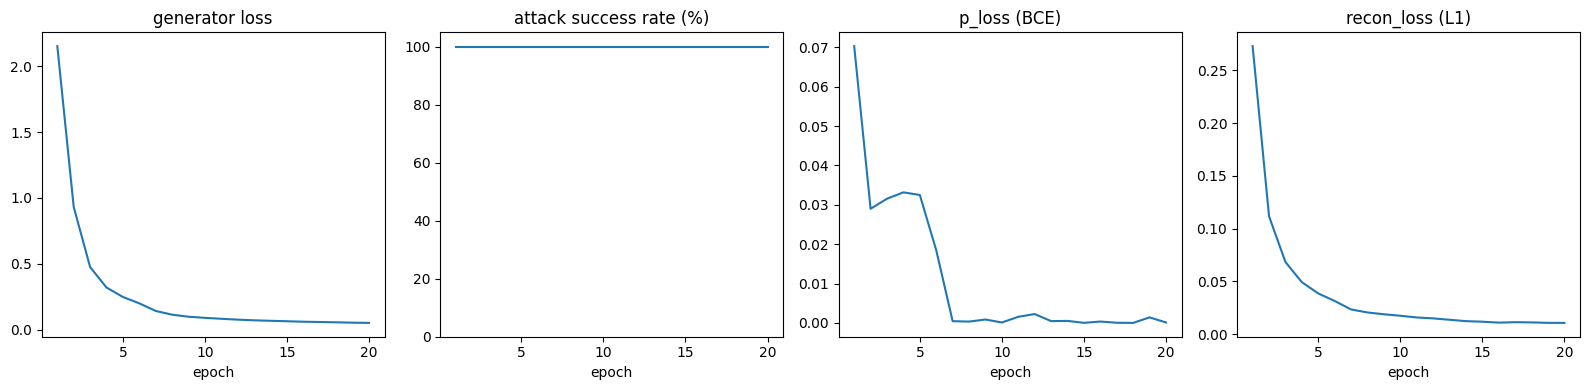

In [11]:
G.eval()
with torch.no_grad():
    adv_eval = torch.cat([G(b.to(DEVICE)).detach().cpu() for b in batches(X_eval_fake, 64, shuffle=False)])
p_clean = real_prob(victim, X_eval_fake)
p_adv   = real_prob(victim, adv_eval)

acc_clean = (p_clean < 0.5).float().mean().item()
acc_adv   = (p_adv   < 0.5).float().mean().item()   # accuracy AFTER attack
asr       = (p_adv   > 0.5).float().mean().item()   # attack success rate

print(f"Deep4SNet accuracy on fakes: clean {acc_clean*100:5.1f}% -> adversarial {acc_adv*100:5.1f}%")
print(f"Attack success rate (fakes classified as Real): {asr*100:.1f}%")

# training curves
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].plot(history["epoch"], history["loss"]);
ax[0].set_title("generator loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["epoch"], [s*100 for s in history["success"]])

ax[1].set_title("attack success rate (%)")
ax[1].set_xlabel("epoch")
ax[1].set_ylim(0, 105)

ax[2].plot(history["epoch"], history["p_loss"])
ax[2].set_title("p_loss (BCE)")
ax[2].set_xlabel("epoch")

ax[3].plot(history["epoch"], history["recon_loss"])
ax[3].set_title("recon_loss (L1)")
ax[3].set_xlabel("epoch")


plt.tight_layout()
plt.savefig("plots/10.1 Attack Loss Metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Visualisation

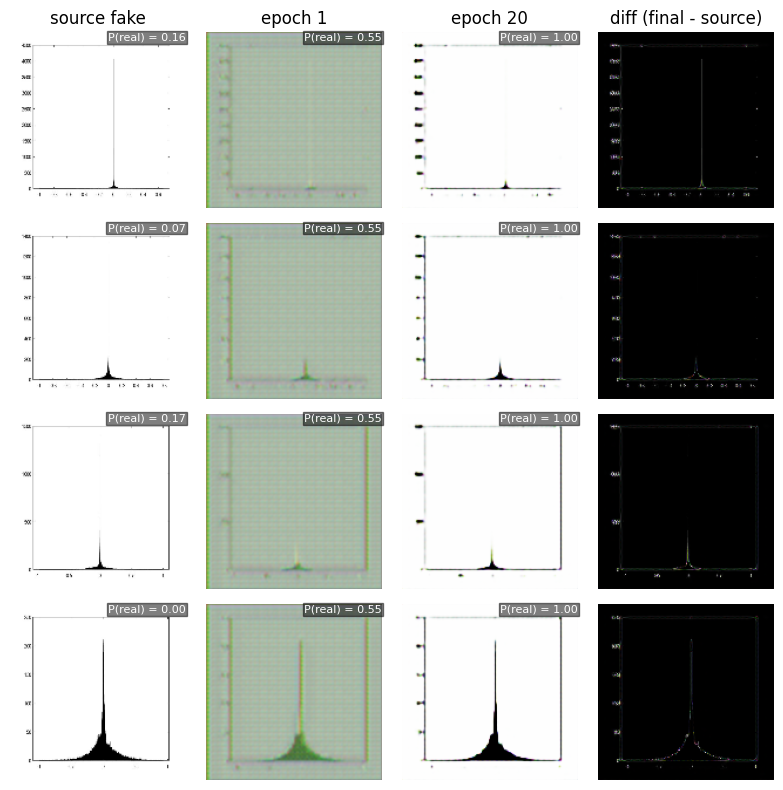

In [12]:
snap_keys = sorted(snapshots.keys())
n_rows    = 4

n_cols = len(snap_keys) + 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))

for r in range(n_rows):
    axes[r, 0].imshow(snap_src[r].permute(1, 2, 0).cpu().numpy());
    axes[r, 0].axis("off")
    axes[r, 0]

    if r == 0: axes[r, 0].set_title("source fake")
    for c, ep in enumerate(snap_keys, start=1):
        grid = snapshots[ep]['grid']
        prob = snapshots[ep]['prob']
        axes[r, c].imshow(grid[r])
        axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(f"epoch {ep}")

    for c in range(0, len(snap_keys)+1):
        # If its the first column, ie the source fake, compute the P(real) for that input. Otherwise, use the stored P(real) from the snapshot
        if c == 0:
            prob = real_prob(victim, snap_src).cpu().numpy()
        else:
            prob = snapshots[snap_keys[c-1]]['prob']
        # Add a lil `P(real) = ...` on the top right
        axes[r, c].text(1, 1, f"P(real) = {prob[r][0]:.2f}", transform=axes[r, c].transAxes, ha='right', va='top', fontsize=8, color='white', bbox=dict(facecolor='black', alpha=0.5, pad=1))
    
    # Show the difference between the source and final adversarial output
    diff = (snapshots[snap_keys[-1]]['grid'][r] - snap_src[r].permute(1, 2, 0).cpu().numpy())
    diff = np.abs(diff)  # show absolute difference
    # diff = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
    # diff = diff.abs()  # show absolute difference
    # print(type(diff), diff.shape, diff.min(), diff.max())
    axes[r, -1].imshow(diff)
    axes[r, -1].axis("off")
    if r == 0: axes[r, -1].set_title("diff (final - source)")

plt.tight_layout()
plt.savefig("plots/10.2 Visualization.png", dpi=300, bbox_inches="tight")
plt.show()



# # a few final adversarial examples with their P(real)
# fig, ax = plt.subplots(1, 6, figsize=(16, 3))
# with torch.no_grad():
#     show = G(X_eval_fake[:6].to(DEVICE)).clamp(0, 1).cpu()
#     ps   = victim(show.to(DEVICE)).squeeze(1).cpu()
# for i in range(6):
#     ax[i].imshow(show[i].permute(1, 2, 0).numpy())
#     ax[i].set_title(f"P(real)={ps[i]:.2f}", color=("green" if ps[i] > 0.5 else "red"))
#     ax[i].axis("off")
# plt.tight_layout(); plt.savefig("plots/attack2_examples.png", dpi=150, bbox_inches="tight"); plt.show()

<!-- ## 9. Download plots -->

In [16]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())

In [17]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

/kaggle/working/plots.zip